In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_raw = pd.read_csv("../data/telco_churn.csv")

In [8]:
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df = df_raw.copy()

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

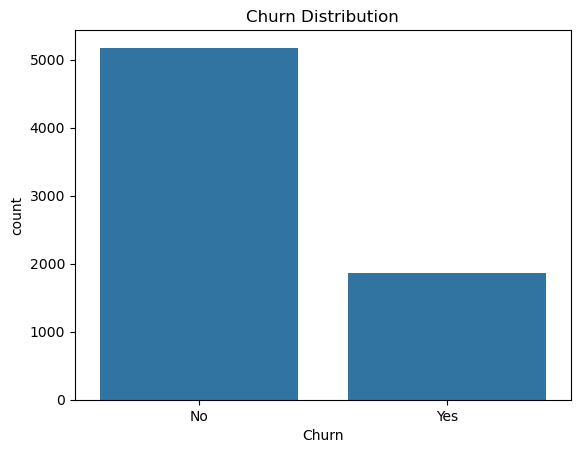

In [14]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [15]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


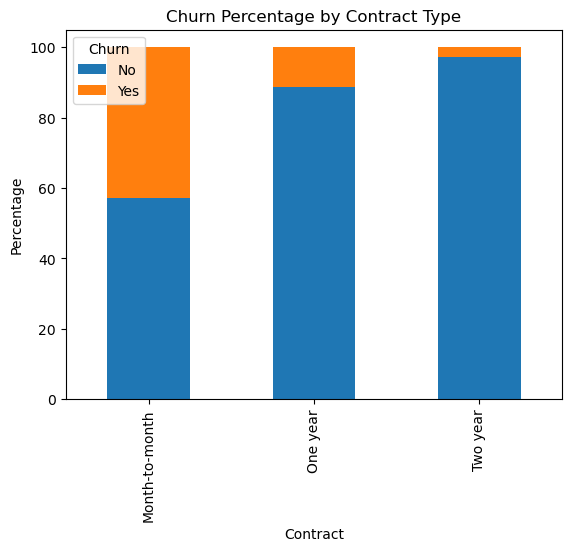

In [16]:
# Feature_analysis 1: Contract type VS Churn
contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn Percentage by Contract Type")
plt.ylabel("Percentage")
plt.show()

# key insight
# Month-to-month → very high churn %
# Two-year → very low churn %

In [17]:
# Feature_analysis 2: Internet Service VS Churn
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
internet_churn

# key insight:
# fiber optic has higher churn rate because of higher fabric cost -> higher churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [18]:
# Feature_analysis 3: Payment method VS Churn
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
payment_churn

# key insight:
# Electronic check has higher churn 

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [19]:
# Tenure binning
df["tenure_group"] = pd.cut(df["tenure"],
                            bins=[0,12,24,48,60,72],
                            labels=["0-12","12-24","24-48","48-60","60-72"])


In [20]:
pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100

# key insight:
# 0-12 tenure_group has higher churn rate

Churn,No,Yes
tenure_group,,
0-12,52.321839,47.678161
12-24,71.289062,28.710938
24-48,79.611041,20.388959
48-60,85.576923,14.423077
60-72,93.390192,6.609808


Summary of key-insights: 

Customers on month-to-month contracts show significantly higher churn rates.

Customers with tenure less than 12 months are most likely to churn.

Fiber optic users show higher churn compared to DSL.

Customers using electronic check payment have elevated churn risk.

In [21]:
OnlineSecurity_churn = pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index") * 100
OnlineSecurity_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [22]:
TechSupport_churn = pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100
TechSupport_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [23]:
SeniorCitizen_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100
SeniorCitizen_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [24]:
PaperlessBilling_churn = pd.crosstab(df["PaperlessBilling"], df["Churn"], normalize="index") * 100
PaperlessBilling_churn

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092
